In [1]:
%pip install onnxruntime ultralytics psutil matplotlib seaborn opencv-python pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\User\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


# Optimisation of YOLOv8s Extraction on CPU using ONNX Runtime


In [2]:
# Cell 1: Setup & Environment Loading
import os
import cv2
import time
import psutil
import urllib.request
import numpy as np
import onnxruntime as ort
import matplotlib.pyplot as plt
import seaborn as sns

# Download 4 sample images to simulate a real batch
image_urls = [
    "https://raw.githubusercontent.com/ultralytics/yolov5/master/data/images/zidane.jpg",
    "https://raw.githubusercontent.com/ultralytics/yolov5/master/data/images/bus.jpg",
    "https://raw.githubusercontent.com/ultralytics/yolov5/master/data/images/zidane.jpg",
    "https://raw.githubusercontent.com/ultralytics/yolov5/master/data/images/bus.jpg"
]
image_paths = []

os.makedirs("sample_images", exist_ok=True)
for i, url in enumerate(image_urls):
    path = f"sample_images/img_{i}.jpg"
    if not os.path.exists(path):
        urllib.request.urlretrieve(url, path)
    image_paths.append(path)

print(f"Environment setup complete. Downloaded {len(image_paths)} images for batching.")

Environment setup complete. Downloaded 4 images for batching.


In [3]:
# Cell 2:ONNX Export
from ultralytics import YOLO

# Load the base YOLOv8s model
model = YOLO('yolov8s.pt')

# Export with strict optimization: FP32 precision, dynamic batching, simplified graph, ONNX opset 17
export_path = model.export(
    format='onnx', 
    dynamic=True, 
    simplify=True, 
    half=False, 
    opset=17
)

print(f"\nOptimization Complete! Model strictly exported to: {export_path}")

Ultralytics 8.4.41  Python-3.11.9 torch-2.11.0+cpu CPU (Intel Core i7-6700HQ 2.60GHz)
YOLOv8s summary (fused): 72 layers, 11,156,544 parameters, 0 gradients, 28.6 GFLOPs

PyTorch: starting from 'yolov8s.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (21.5 MB)

ONNX: starting export with onnx 1.21.0 opset 17...
ONNX: slimming with onnxslim 0.1.91...
ONNX: export success  7.2s, saved as 'yolov8s.onnx' (42.9 MB)

Export complete (8.1s)
Results saved to C:\Users\User\Desktop\Projects\AI-ML-experements\ONNX
Predict:         yolo predict task=detect model=yolov8s.onnx imgsz=640 
Validate:        yolo val task=detect model=yolov8s.onnx imgsz=640 data=coco.yaml  
Visualize:       https://netron.app

Optimization Complete! Model strictly exported to: yolov8s.onnx


In [4]:
# Cell 3: Strict ONNX Runtime CPU Tuning
def create_ort_session(model_path, num_threads):
    """
    Creates an ONNX Runtime InferenceSession with maximized CPU optimizations.
    """
    sess_options = ort.SessionOptions()
    
    # 1. Enable all graph optimizations (fusing nodes, constant folding, etc.)
    sess_options.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL
    
    # 2. Sequential execution to prevent inter-node contention
    sess_options.execution_mode = ort.ExecutionMode.ORT_SEQUENTIAL
    sess_options.inter_op_num_threads = 1
    
    # 3. Exact threading for intra-node parallelism
    sess_options.intra_op_num_threads = num_threads
    
    # 4. Optional: Enable profiling to track operator execution times
    sess_options.enable_profiling = True

    # Bind strictly to CPU execution
    session = ort.InferenceSession(
        model_path, 
        sess_options=sess_options,
        providers=['CPUExecutionProvider']
    )
    return session

# Calculate exact physical cores (excluding hyperthreaded/logical cores)
physical_cores = psutil.cpu_count(logical=False)
model_path = 'yolov8s.onnx'

# Instantiate the optimal session
optimal_session = create_ort_session(model_path, physical_cores)
print(f"Created Optimal ONNX Session utilizing exactly {physical_cores} Physical Cores.")

Created Optimal ONNX Session utilizing exactly 4 Physical Cores.


In [5]:
# Cell 4: Pure Numpy Preprocessing & Batching
def preprocess_images(img_paths, img_size=(640, 640)):
    """
    Highly efficient raw preprocessing pipeline.
    Avoids OOP overheads (like Ultralytics Predictor) and directly builds batch tensors.
    """
    batch = []
    for path in img_paths:
        # Load and convert from BGR to RGB
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Resize safely
        img = cv2.resize(img, img_size, interpolation=cv2.INTER_LINEAR)
        
        # Normalize directly to float32 (Division maps 0-255 to 0.0-1.0)
        img = img.astype(np.float32) / 255.0
        
        # HWC (Height, Width, Channels) -> CHW (Channels, Height, Width)
        img = img.transpose(2, 0, 1)
        batch.append(img)
        
    # Stack [CHW, CHW...] -> [B, C, H, W] tensor
    batch_tensor = np.stack(batch)
    return batch_tensor

# Generate the strictly formed float32 input block
input_tensor = preprocess_images(image_paths)
print(f"Batch Tensor generated successfully: {input_tensor.shape} | Dtype: {input_tensor.dtype}")

Batch Tensor generated successfully: (4, 3, 640, 640) | Dtype: float32


In [6]:
# Cell 5: Maximum Throughput Benchmark
input_name = optimal_session.get_inputs()[0].name
batch_size = input_tensor.shape[0]

# --- Warmup Phase ---
print("Running Warmup iterations...")
for _ in range(5):
    _ = optimal_session.run(None, {input_name: input_tensor})

# --- Benchmark Phase ---
iterations = 50
print(f"Running Benchmark ({iterations} iterations, batch size {batch_size})...")

start_time = time.perf_counter()
for _ in range(iterations):
    outputs = optimal_session.run(None, {input_name: input_tensor})
end_time = time.perf_counter()

total_time = end_time - start_time
total_images = batch_size * iterations
throughput = total_images / total_time
latency = (total_time / iterations) * 1000  # Latency per batch in ms

print("-" * 50)
print("BENCHMARK RESULTS")
print(f"Total Time: {total_time:.2f} seconds")
print(f"Absolute Throughput: {throughput:.2f} Images / Second (FPS)")
print(f"Batch Latency: {latency:.2f} ms")
print("-" * 50)

Running Warmup iterations...
Running Benchmark (50 iterations, batch size 4)...
--------------------------------------------------
BENCHMARK RESULTS
Total Time: 38.23 seconds
Absolute Throughput: 5.23 Images / Second (FPS)
Batch Latency: 764.67 ms
--------------------------------------------------


Running CPU Thread Contention Analysis...


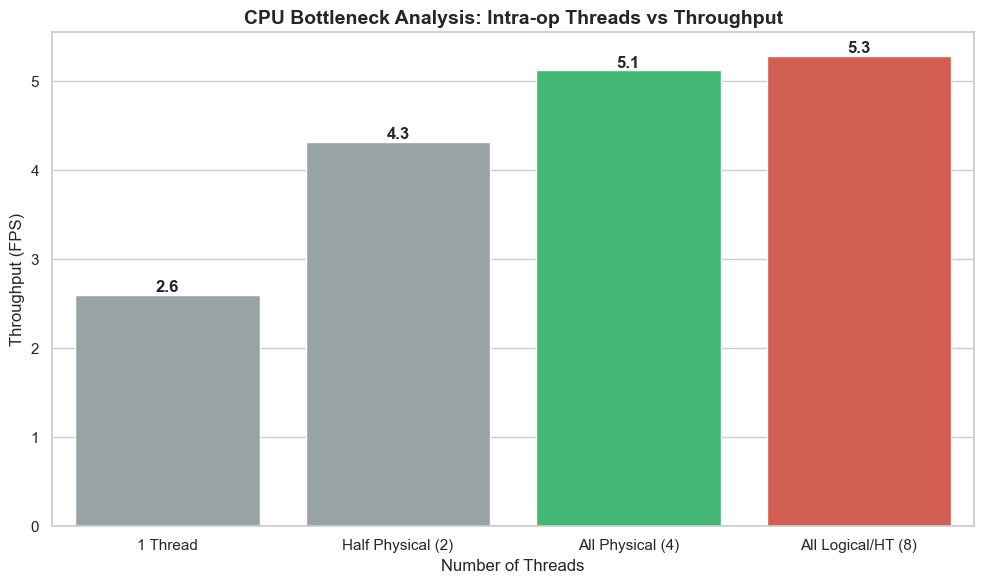

In [7]:
# Cell 6: Bottleneck Visualization (Thread Contention Analysis)
import logging
# Suppress profiling logs flooding the output
logging.getLogger("onnxruntime").setLevel(logging.ERROR)

logical_cores = psutil.cpu_count(logical=True)
half_cores = max(1, physical_cores // 2)

thread_configs = {
    "1 Thread": 1,
    f"Half Physical ({half_cores})": half_cores,
    f"All Physical ({physical_cores})": physical_cores,
    f"All Logical/HT ({logical_cores})": logical_cores
}

results_fps = []
labels = []

print("Running CPU Thread Contention Analysis...")

for label, threads in thread_configs.items():
    sess = create_ort_session(model_path, threads)
    inp_name = sess.get_inputs()[0].name
    
    # Warmup
    for _ in range(3):
        sess.run(None, {inp_name: input_tensor})
        
    start_t = time.perf_counter()
    for _ in range(20):
         sess.run(None, {inp_name: input_tensor})
    end_t = time.perf_counter()
    
    fps = (input_tensor.shape[0] * 20) / (end_t - start_t)
    results_fps.append(fps)
    labels.append(label)

# --- Plotting ---
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Create a color palette: gray for generic, green for Physical, red for Logical/HT
colors = []
for label in labels:
    if "Physical" in label and "Half" not in label:
        colors.append("#2ecc71") # Green
    elif "Logical" in label:
        colors.append("#e74c3c") # Red
    else:
        colors.append("#95a5a6") # Gray

ax = sns.barplot(x=labels, y=results_fps, hue=labels, palette=colors, legend=False)
ax.set_title("CPU Bottleneck Analysis: Intra-op Threads vs Throughput", fontsize=14, fontweight='bold')
ax.set_xlabel("Number of Threads", fontsize=12)
ax.set_ylabel("Throughput (FPS)", fontsize=12)

# Annotate values
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()



Starting massive benchmark grid search (this could take a couple of minutes)...
B:1 | Sequential | Intra:1 -> 2.6 FPS
B:1 | Sequential | Intra:2 -> 4.4 FPS
B:1 | Sequential | Intra:4 -> 5.3 FPS
B:1 | Sequential | Intra:6 -> 6.8 FPS
B:1 | Sequential | Intra:8 -> 7.2 FPS
B:1 | Sequential | Intra:12 -> 2.0 FPS
B:1 | Sequential | Intra:16 -> 1.2 FPS
B:1 | Parallel (Inter=2) | Intra:1 -> 2.5 FPS
B:1 | Parallel (Inter=2) | Intra:2 -> 3.9 FPS
B:1 | Parallel (Inter=2) | Intra:4 -> 5.7 FPS
B:1 | Parallel (Inter=2) | Intra:6 -> 6.7 FPS
B:1 | Parallel (Inter=2) | Intra:8 -> 4.0 FPS
B:1 | Parallel (Inter=2) | Intra:12 -> 1.7 FPS
B:1 | Parallel (Inter=2) | Intra:16 -> 1.1 FPS
B:4 | Sequential | Intra:1 -> 2.6 FPS
B:4 | Sequential | Intra:2 -> 4.3 FPS
B:4 | Sequential | Intra:4 -> 5.2 FPS
B:4 | Sequential | Intra:6 -> 5.9 FPS
B:4 | Sequential | Intra:8 -> 6.2 FPS
B:4 | Sequential | Intra:12 -> 2.0 FPS
B:4 | Sequential | Intra:16 -> 1.4 FPS
B:4 | Parallel (Inter=2) | Intra:1 -> 2.4 FPS
B:4 | Parallel

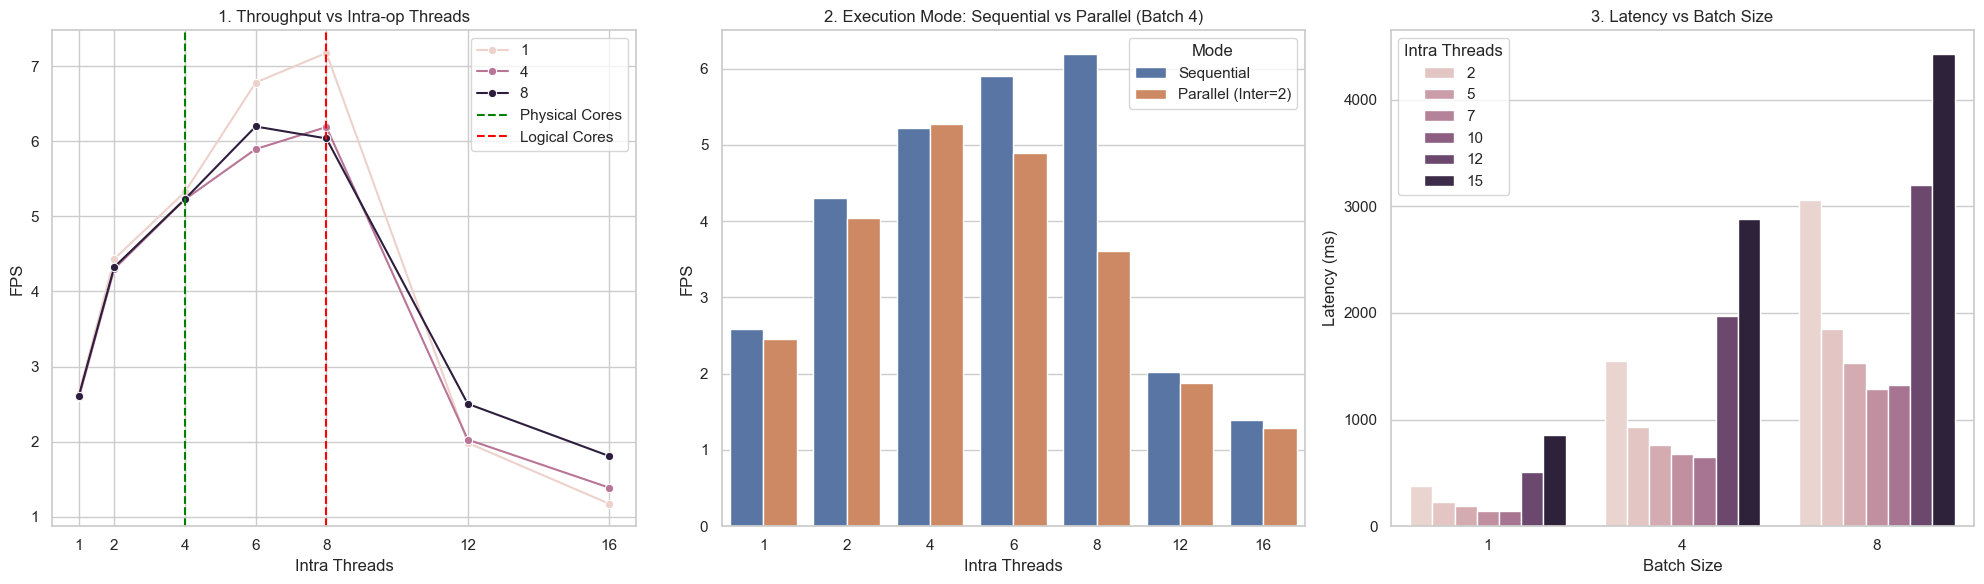

In [ ]:
# Cell 7: Grid Search Benchmark (Batch Size vs Intra Threads vs Execution Mode)
import pandas as pd

# Benchmark Configuration
model_path = "yolov8s.onnx"
img_size = 640
iterations = 20

# Grid Search Parameters
batch_sizes = [1, 4, 8]
# We exceed typical physical core counts to prove the throughput drop-off
intra_threads = [1, 2, 4, 6, 8, 12, 16] 
execution_modes = [
    (ort.ExecutionMode.ORT_SEQUENTIAL, 1, "Sequential"),
    (ort.ExecutionMode.ORT_PARALLEL, 2, "Parallel (Inter=2)")
]

results = []

for batch in batch_sizes:
    # Create a dummy tensor for benchmarking
    dummy_input = np.random.randn(batch, 3, img_size, img_size).astype(np.float32)
    
    for mode, inter_op, mode_name in execution_modes:
        for intra_op in intra_threads:
            
            # Configure ONNX Runtime Session
            opt = ort.SessionOptions()
            opt.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL
            opt.execution_mode = mode
            opt.inter_op_num_threads = inter_op
            opt.intra_op_num_threads = intra_op
            
            try:
                session = ort.InferenceSession(model_path, opt, providers=['CPUExecutionProvider'])
                input_name = session.get_inputs()[0].name
                
                # Warmup Phase
                for _ in range(3):
                    session.run(None, {input_name: dummy_input})
                    
                # Measure Inference Phase
                start = time.perf_counter()
                for _ in range(iterations):
                    session.run(None, {input_name: dummy_input})
                end = time.perf_counter()
                
                fps = (iterations * batch) / (end - start)
                latency = ((end - start) / iterations) * 1000 # in ms
                
                results.append({
                    "Batch Size": batch,
                    "Mode": mode_name,
                    "Intra Threads": intra_op,
                    "FPS": fps,
                    "Latency (ms)": latency
                })
                print(f"B:{batch} | {mode_name} | Intra:{intra_op} -> {fps:.1f} FPS")
            except Exception as e:
                print(f"Error on Intra:{intra_op}, Mode:{mode_name} -> {e}")

df = pd.DataFrame(results)


sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: Throughput vs Intra-op Threads (Sequential)
sns.lineplot(data=df[df['Mode'] == 'Sequential'], x='Intra Threads', y='FPS', hue='Batch Size', marker='o', ax=axes[0])
axes[0].set_title("1. Throughput vs Intra-op Threads")
axes[0].set_xticks(intra_threads)
axes[0].axvline(4, color='green', linestyle='--', label='Physical Cores')
axes[0].axvline(8, color='red', linestyle='--', label='Logical Cores')
axes[0].legend()

# Plot 2: Sequential vs Parallel Execution Modes
sns.barplot(data=df[df['Batch Size'] == 4], x='Intra Threads', y='FPS', hue='Mode', ax=axes[1])
axes[1].set_title("2. Execution Mode: Sequential vs Parallel (Batch 4)")

# Plot 3: Latency vs Batch Size
sns.barplot(data=df[df['Mode'] == 'Sequential'], x='Batch Size', y='Latency (ms)', hue='Intra Threads', ax=axes[2])
axes[2].set_title("3. Latency vs Batch Size")

plt.tight_layout()
plt.show()